# Predicting Household Electric Power Consumption

This project is an end-to-end analysis of the UCI *Individual Household Electric Power Consumption* dataset.

- convert minute-level readings into **daily energy demand**;
- create **lag, rolling-window, calendar, and sub-metering share features**;
- visualise demand with **calendar-style heatmaps, day-hour heatmaps, lag plots, autocorrelation, and error diagnostics**;
- compare a **naïve persistence baseline**, **Ridge regression**, **Random Forest**, and **Gradient Boosting** for forecasting.

**Can yesterday's electricity use, recent rolling trends, calendar timing, and appliance-zone shares be used to forecast next-day household electricity demand?**

The target in this notebook is daily average `Global_active_power`. The analysis is written as a reproducible workflow for a final statistical project: data acquisition, cleaning, feature engineering, EDA, hypothesis testing, model comparison, model diagnostics, and recommendations.

In [1]:
# ================================================================
# 1. Imports and project folders
# Load packages, suppress warnings, configure display settings, and create project folders for data, outputs, figures, and tables.
# ================================================================
from pathlib import Path
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
# Ignore non-critical warnings to keep output clean.
pd.set_option("display.max_columns", 120)
# Display a larger number of columns in dataframe outputs.

ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
OUT = ROOT / "outputs_original"
FIG = OUT / "figures"
TAB = OUT / "tables"
for path in [RAW, OUT, FIG, TAB]:
# Ensure the data/output directories exist before writing any files.
    path.mkdir(parents=True, exist_ok=True)

print("Folders created:")
print("Raw:", RAW)
print("Outputs:", OUT)

Folders created:
Raw: /Users/piyushpravin/Downloads/data/raw
Outputs: /Users/piyushpravin/Downloads/outputs_original


## 2. Data Download and Loading

If the dataset is not already present, the notebook attempts to download it from the UCI Machine Learning Repository. If automatic download is blocked, manually place `household_power_consumption.txt` in `data/raw/`.

In [2]:
# ================================================================
# 2. Download/extract dataset if needed
# Download the UCI zip archive if missing, extract it locally, or confirm the existing raw text file.
# ================================================================
DATA_URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
# Define the remote dataset URL for the UCI zip archive.
ZIP_FILE = RAW / "individual_household_power_consumption.zip"
TXT_FILE = RAW / "household_power_consumption.txt"

if not TXT_FILE.exists():
# Download or extract the dataset only if the raw text file is missing.
    if not ZIP_FILE.exists():
        try:
            print("Attempting dataset download...")
            urllib.request.urlretrieve(DATA_URL, ZIP_FILE)
            print("Downloaded:", ZIP_FILE)
        except Exception as err:
            print("Download did not complete. Manually download the file from UCI and place it in data/raw/.")
            print("Reason:", err)
    if ZIP_FILE.exists():
        with zipfile.ZipFile(ZIP_FILE, "r") as archive:
            archive.extractall(RAW)
        print("Extraction complete.")
else:
    print("Dataset found locally:", TXT_FILE)

Dataset found locally: /Users/piyushpravin/Downloads/data/raw/household_power_consumption.txt


In [3]:
# ================================================================
# 3. Read minute-level data
# Read the raw dataset, convert numeric values, parse timestamps, and inspect the loaded dataframe.
# ================================================================
if not TXT_FILE.exists():
# Download or extract the dataset only if the raw text file is missing.
    raise FileNotFoundError("household_power_consumption.txt not found in data/raw/. Download the UCI file first.")

raw = pd.read_csv(TXT_FILE, sep=";", na_values=["?"], low_memory=False)
# Load the raw semicolon-delimited data and treat ? as missing values.

num_vars = [
    "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity",
    "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]
for col in num_vars:
# Convert measurement columns from strings to numeric values.
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw["timestamp"] = pd.to_datetime(
# Combine the Date and Time columns into a single datetime index.
    raw["Date"].astype(str) + " " + raw["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)
raw = raw.drop(columns=["Date", "Time"]).sort_values("timestamp")
# Drop the original date/time strings after parsing and sort chronologically.

print("Raw shape:", raw.shape)
print("Date range:", raw["timestamp"].min(), "to", raw["timestamp"].max())
display(raw.head())
display(raw[num_vars].describe().T)

Raw shape: (2075259, 8)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


## 3. Data Quality and Cleaning Strategy

1. removes invalid timestamps and duplicate timestamps;
2. applies time-aware interpolation for short missing gaps;
3. aggregates the cleaned minute-level records to hourly and daily datasets;
4. models daily energy demand.

In [4]:
# ================================================================
# 4. Quality checks and time-aware interpolation
# Summarise missing values, clean duplicate or invalid timestamps, reindex to a continuous minute timeline, and interpolate short gaps.
# ================================================================
quality = pd.DataFrame({
# Summarise missing values and data types for the raw dataset.
    "missing_count": raw.isna().sum(),
    "missing_percent": raw.isna().mean() * 100,
    "dtype": raw.dtypes.astype(str)
})
quality.to_csv(TAB / "01_missingness_summary.csv")
display(quality)

clean = raw.dropna(subset=["timestamp"]).copy()
# Remove rows with invalid timestamps and keep a clean working copy.
clean = clean.drop_duplicates(subset="timestamp", keep="first")
clean = clean.set_index("timestamp").sort_index()

minute_index = pd.date_range(clean.index.min(), clean.index.max(), freq="min")
# Reindex to a complete minute-level timeline to identify gaps.
clean = clean.reindex(minute_index)
clean.index.name = "timestamp"

clean[num_vars] = clean[num_vars].interpolate(method="time", limit=60, limit_direction="both")
# Interpolate short gaps in the minute-level series using time-aware interpolation.
clean = clean.dropna(subset=num_vars)

print("Clean minute-level shape:", clean.shape)
print("Time coverage after cleaning:", clean.index.min(), "to", clean.index.max())

,missing_count,missing_percent,dtype
Global_active_power,25979,1.251844,float64
Global_reactive_power,25979,1.251844,float64
Voltage,25979,1.251844,float64
Global_intensity,25979,1.251844,float64
Sub_metering_1,25979,1.251844,float64
Sub_metering_2,25979,1.251844,float64
Sub_metering_3,25979,1.251844,float64
timestamp,0,0.000000,datetime64[ns]


Clean minute-level shape: (2050561, 7)
Time coverage after cleaning: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


In [5]:
# ================================================================
# 5. Derived energy variables and aggregation
# Compute energy quantities in kWh, aggregate clean data to hourly and daily summaries, and inspect the results.
# ================================================================
clean["active_energy_kwh"] = clean["Global_active_power"] / 60
# Convert active power from kW per minute into kWh per minute.
clean["submeter_total_kwh"] = (
# Sum the three sub-metered loads and convert from watt-minutes to kWh.
    clean["Sub_metering_1"] + clean["Sub_metering_2"] + clean["Sub_metering_3"]
) / 1000
clean["unmetered_kwh"] = (clean["active_energy_kwh"] - clean["submeter_total_kwh"]).clip(lower=0)
# Estimate unmetered energy as the residual between active power and sub-metering.

hourly = clean.resample("H").agg({
# Aggregate the cleaned minute data to hourly summaries.
    "Global_active_power": "mean",
    "Global_reactive_power": "mean",
    "Voltage": "mean",
    "Global_intensity": "mean",
    "Sub_metering_1": "mean",
    "Sub_metering_2": "mean",
    "Sub_metering_3": "mean",
    "active_energy_kwh": "sum",
    "submeter_total_kwh": "sum",
    "unmetered_kwh": "sum"
}).dropna()

daily = clean.resample("D").agg({
# Aggregate the cleaned minute data to daily summaries for modeling.
    "Global_active_power": "mean",
    "Global_reactive_power": "mean",
    "Voltage": "mean",
    "Global_intensity": "mean",
    "Sub_metering_1": "sum",
    "Sub_metering_2": "sum",
    "Sub_metering_3": "sum",
    "active_energy_kwh": "sum",
    "submeter_total_kwh": "sum",
    "unmetered_kwh": "sum"
}).dropna()

print("Hourly rows:", hourly.shape[0])
print("Daily rows:", daily.shape[0])
display(daily.head())

Hourly rows: 34183
Daily rows: 1433


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,active_energy_kwh,submeter_total_kwh,unmetered_kwh
timestamp,,,,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.0,546.0,4926.0,20.152933,5.472,14.680933
2006-12-17,2.354486,0.156949,240.087028,9.999028,2033.0,4187.0,13341.0,56.507667,19.561,36.946667
2006-12-18,1.530435,0.112356,241.231694,6.421667,1063.0,2621.0,14018.0,36.730433,17.702,19.028433
2006-12-19,1.157079,0.104821,241.999313,4.926389,839.0,7602.0,6197.0,27.769900,14.638,13.131900
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.0,2648.0,14063.0,37.095800,16.711,20.384800


## 4. Feature Engineering for Forecasting

Forecasting features include lagged daily demand, rolling averages/volatility, weekend and month effects, and sub-metering usage shares.

In [6]:
# ================================================================
# 6. Daily forecasting features
# Create calendar, lag, rolling-window, and sub-metering share features for the daily forecasting dataset.
# ================================================================
features = daily.copy()
# Start feature engineering from the daily aggregated dataset.
features["date"] = features.index
features["day_of_week"] = features.index.dayofweek
# Add calendar features from the daily timestamp index.
features["day_name"] = features.index.day_name()
features["month"] = features.index.month
features["quarter"] = features.index.quarter
features["is_weekend"] = features["day_of_week"].isin([5, 6]).astype(int)
features["dow_sin"] = np.sin(2 * np.pi * features["day_of_week"] / 7)
features["dow_cos"] = np.cos(2 * np.pi * features["day_of_week"] / 7)
features["month_sin"] = np.sin(2 * np.pi * features["month"] / 12)
features["month_cos"] = np.cos(2 * np.pi * features["month"] / 12)

for lag in [1, 2, 3, 7, 14, 28]:
# Create lagged targets to capture autoregressive demand patterns.
    features[f"lag_{lag}"] = features["Global_active_power"].shift(lag)

for window in [3, 7, 14, 28]:
# Compute rolling statistics to capture recent demand trends and volatility.
    features[f"rolling_mean_{window}"] = features["Global_active_power"].shift(1).rolling(window).mean()
    features[f"rolling_std_{window}"] = features["Global_active_power"].shift(1).rolling(window).std()

sub_total = features[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].sum(axis=1).replace(0, np.nan)
# Compute sub-metering shares to describe the relative contribution of each zone.
features["kitchen_share"] = features["Sub_metering_1"] / sub_total
features["laundry_share"] = features["Sub_metering_2"] / sub_total
features["hvac_water_share"] = features["Sub_metering_3"] / sub_total
features[["kitchen_share", "laundry_share", "hvac_water_share"]] = features[["kitchen_share", "laundry_share", "hvac_water_share"]].fillna(0)

model_data = features.dropna().copy()
# Drop rows with missing lag or rolling-window values before modeling.
print("Modelling rows after lag creation:", model_data.shape)
display(model_data.head())
model_data.to_csv(OUT / "daily_modelling_dataset.csv")

Modelling rows after lag creation: (1405, 37)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,active_energy_kwh,submeter_total_kwh,unmetered_kwh,date,day_of_week,day_name,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,kitchen_share,laundry_share,hvac_water_share
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-01-13,2.213065,0.201900,239.283611,9.453056,7806.0,2975.0,11341.0,53.113567,22.1220,30.991567,2007-01-13,5,Saturday,1,1,1,-0.974928,-0.222521,0.5,0.866025,1.014789,1.566107,1.496389,1.047485,1.946067,3.053475,1.359095,0.300208,1.382709,0.268388,1.549569,0.516299,1.735055,0.640260,0.352861,0.134482,0.512657
2007-01-14,2.090992,0.157901,238.817806,8.971667,1777.0,4215.0,12991.5,50.183817,18.9835,31.200317,2007-01-14,6,Sunday,1,1,1,-0.781831,0.623490,0.5,0.866025,2.213065,1.014789,1.566107,1.699736,2.426525,2.354486,1.597987,0.599774,1.549220,0.368607,1.568640,0.536603,1.705040,0.594207,0.093608,0.222035,0.684357
2007-01-15,1.492137,0.121431,241.240910,6.261528,1099.0,2239.0,15163.0,35.811300,18.5010,17.310300,2007-01-15,0,Monday,1,1,0,0.000000,1.000000,0.5,0.866025,2.090992,2.213065,1.014789,1.556500,1.909031,1.530435,1.772949,0.659417,1.605114,0.421153,1.544673,0.501698,1.695630,0.585564,0.059402,0.121020,0.819577
2007-01-16,1.171114,0.128769,241.944757,4.975972,2063.0,644.0,6583.0,28.106733,9.2900,18.816733,2007-01-16,1,Tuesday,1,1,0,0.781831,0.623490,0.5,0.866025,1.492137,2.090992,2.213065,1.297954,0.881414,1.157079,1.932065,0.385847,1.595919,0.423089,1.514895,0.490659,1.694262,0.586009,0.222067,0.069322,0.708611
2007-01-17,1.977561,0.139411,241.005250,8.283889,3500.0,5737.0,16064.0,47.461467,25.3010,22.160467,2007-01-17,2,Wednesday,1,1,0,0.974928,-0.222521,0.5,0.866025,1.171114,1.492137,2.090992,1.496389,0.704204,1.545658,1.584748,0.466880,1.577799,0.440342,1.535588,0.467447,1.694763,0.585538,0.138334,0.226750,0.634916


## 5. Exploratory Data Analysis

The following EDA uses visuals :

- data availability overview;
- monthly demand heatmap by year;
- day-of-week by hour heatmap;
- rolling mean and rolling volatility;
- lag scatterplots;
- autocorrelation plot.

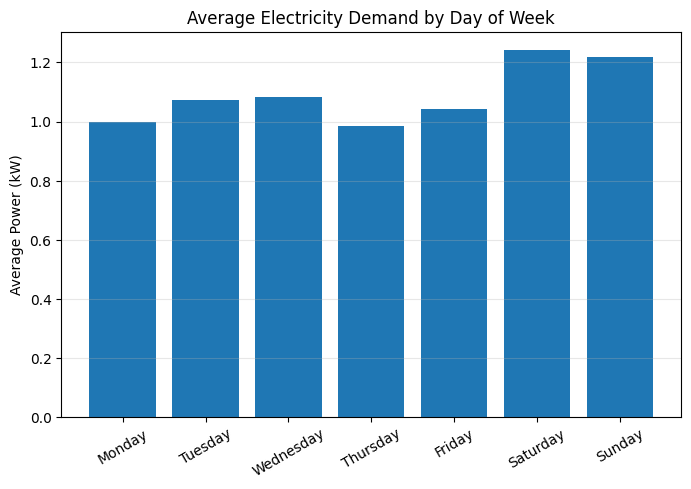

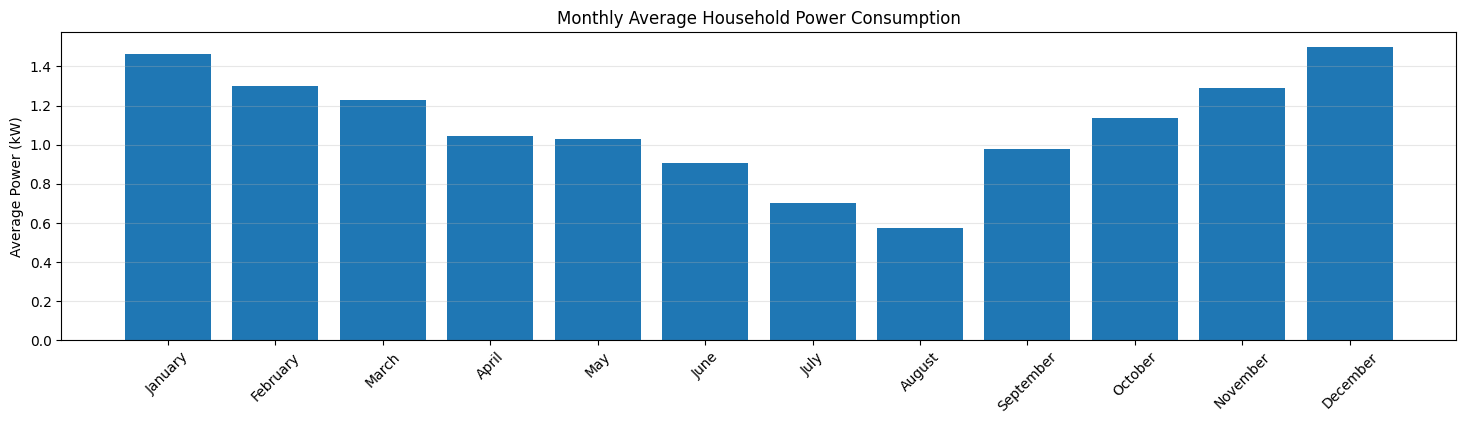

In [7]:
# Average power by day of week
# Plot summary charts of average daily power by weekday and by month.
dow_bar = daily.copy()
dow_bar["day_name"] = dow_bar.index.day_name()

mean_dow = dow_bar.groupby("day_name")["Global_active_power"].mean()
# Calculate average daily demand by day of week.

# Sort Monday → Sunday
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mean_dow = mean_dow.reindex(order)

plt.figure(figsize=(8,5))
plt.bar(mean_dow.index, mean_dow.values)
plt.title("Average Electricity Demand by Day of Week")
plt.ylabel("Average Power (kW)")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.savefig(FIG / "11_bar_day_of_week.png", dpi=300)
plt.show()

# Monthly average
monthly_bar = daily.copy()
monthly_bar["month_name"] = monthly_bar.index.month_name()

monthly_avg = monthly_bar.groupby("month_name")["Global_active_power"].mean()
# Calculate monthly average daily demand for seasonality inspection.

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly_avg = monthly_avg.reindex(month_order)

plt.figure(figsize=(18,4))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title("Monthly Average Household Power Consumption")
plt.ylabel("Average Power (kW)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.savefig(FIG / "12_bar_monthly.png", dpi=300)
plt.show()

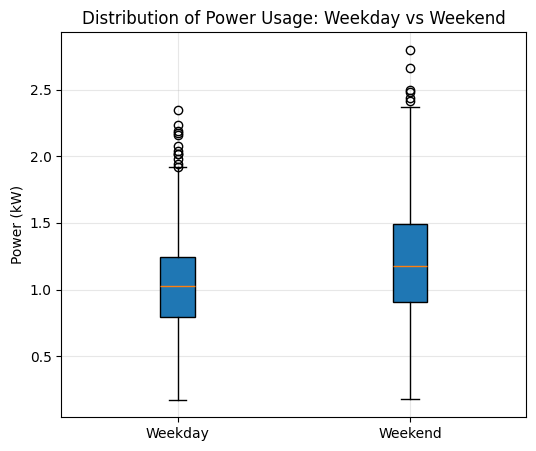

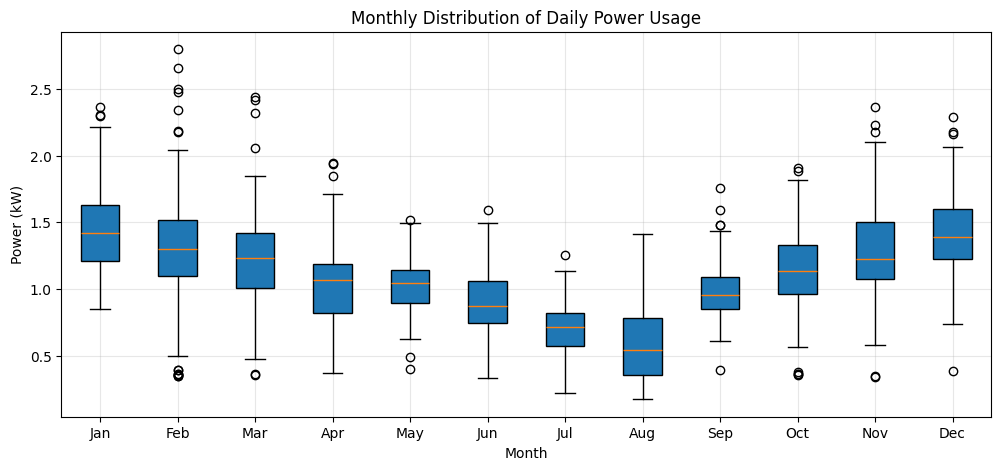

In [8]:
# Boxplot weekday vs weekend
# Plot weekday/weekend and monthly boxplots to compare demand distributions.
box_df = model_data.copy()

labels = ["Weekday", "Weekend"]
# Prepare weekday and weekend demand distributions for boxplot comparison.
data = [
    box_df[box_df["is_weekend"]==0]["Global_active_power"],
    box_df[box_df["is_weekend"]==1]["Global_active_power"]
]

plt.figure(figsize=(6,5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title("Distribution of Power Usage: Weekday vs Weekend")
plt.ylabel("Power (kW)")
plt.grid(alpha=0.3)
plt.savefig(FIG / "13_box_weekend.png", dpi=300)
plt.show()


# Monthly boxplot
monthly_box = model_data.copy()
monthly_box["month"] = monthly_box.index.month

data = [monthly_box[monthly_box["month"]==m]["Global_active_power"] for m in range(1,13)]
# Collect monthly demand values for a series of boxplots.

plt.figure(figsize=(12,5))
plt.boxplot(data, patch_artist=True)
plt.title("Monthly Distribution of Daily Power Usage")
plt.xlabel("Month")
plt.ylabel("Power (kW)")
plt.xticks(range(1,13),
           ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.grid(alpha=0.3)
plt.savefig(FIG / "14_box_month.png", dpi=300)
plt.show()

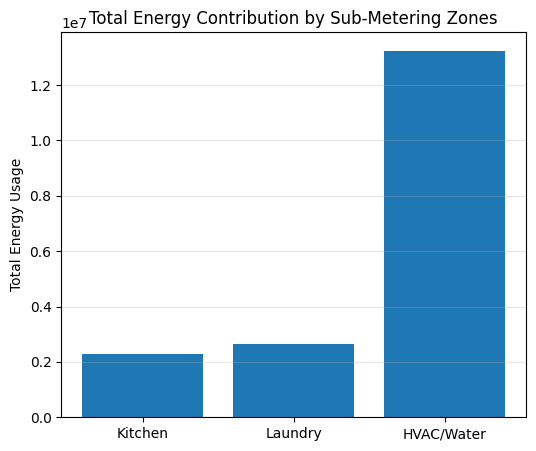

In [9]:
# Sub-metering share
# Plot total energy contributions by sub-metering zones.
sub_totals = daily[["Sub_metering_1","Sub_metering_2","Sub_metering_3"]].sum()

labels = ["Kitchen", "Laundry", "HVAC/Water"]
# Set labels for the sub-metering zone contribution chart.
plt.figure(figsize=(6,5))
plt.bar(labels, sub_totals.values)
plt.title("Total Energy Contribution by Sub-Metering Zones")
plt.ylabel("Total Energy Usage")
plt.grid(axis='y', alpha=0.3)
plt.savefig(FIG / "15_submeter_bar.png", dpi=300)
plt.show()

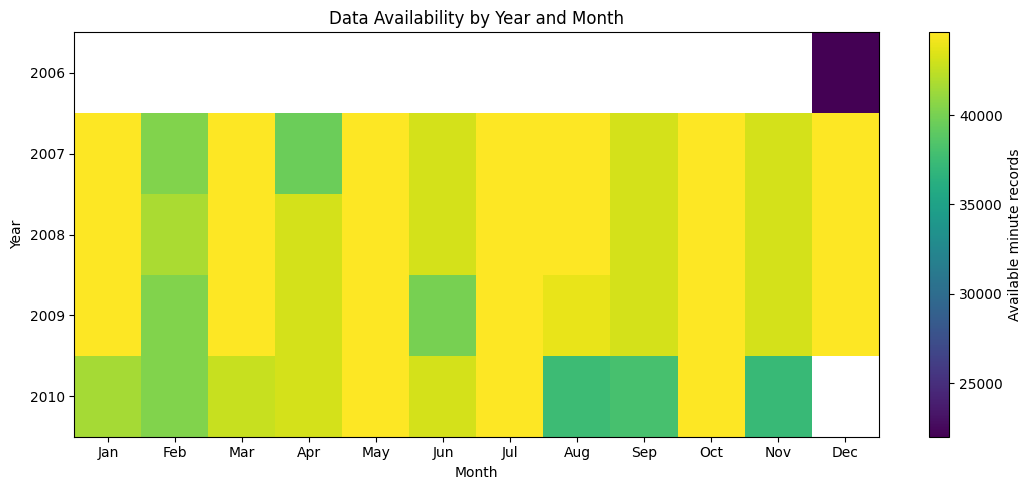

In [10]:
# ================================================================
# 7. Visual 1: Data availability by year and month
# Visualise daily data availability by year and month with a heatmap.
# ================================================================
availability = clean["Global_active_power"].resample("D").count().to_frame("minute_count")
# Count the number of available minute records per day for data coverage analysis.
availability["year"] = availability.index.year
availability["month"] = availability.index.month
availability_month = availability.groupby(["year", "month"])["minute_count"].sum().unstack()
# Pivot the daily availability counts into a year-month matrix for heatmapping.

plt.figure(figsize=(11, 5))
plt.imshow(availability_month, aspect="auto")
plt.colorbar(label="Available minute records")
plt.xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(range(len(availability_month.index)), availability_month.index)
plt.title("Data Availability by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig(FIG / "01_data_availability_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

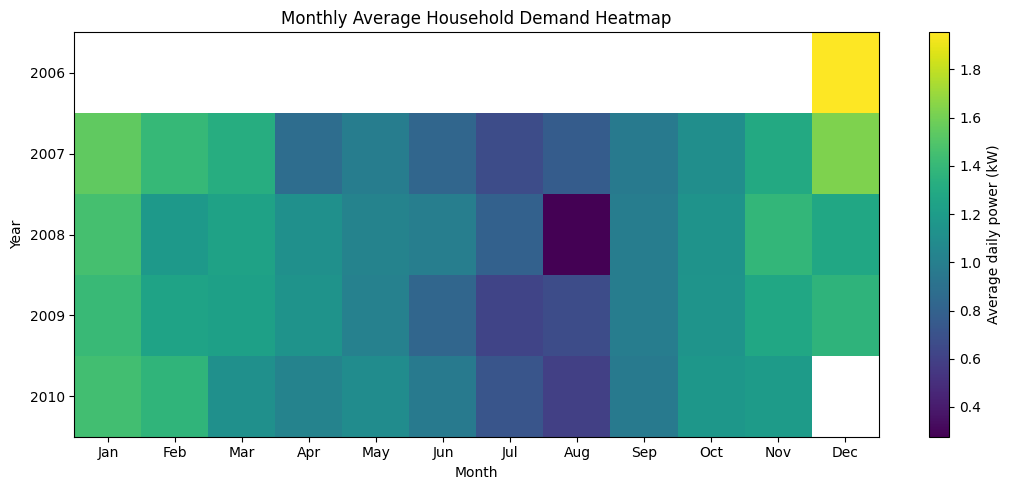

In [11]:
# ================================================================
# 8. Visual 2: Monthly demand heatmap by year
# Visualise monthly average daily demand across years to highlight seasonal patterns.
# ================================================================
monthly_power = daily["Global_active_power"].resample("M").mean().to_frame("avg_power")
monthly_power["year"] = monthly_power.index.year
monthly_power["month"] = monthly_power.index.month
monthly_matrix = monthly_power.pivot(index="year", columns="month", values="avg_power")
# Create a matrix of monthly average demand values by year for visualisation.

plt.figure(figsize=(11, 5))
plt.imshow(monthly_matrix, aspect="auto")
plt.colorbar(label="Average daily power (kW)")
plt.xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(range(len(monthly_matrix.index)), monthly_matrix.index)
plt.title("Monthly Average Household Demand Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig(FIG / "02_monthly_demand_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

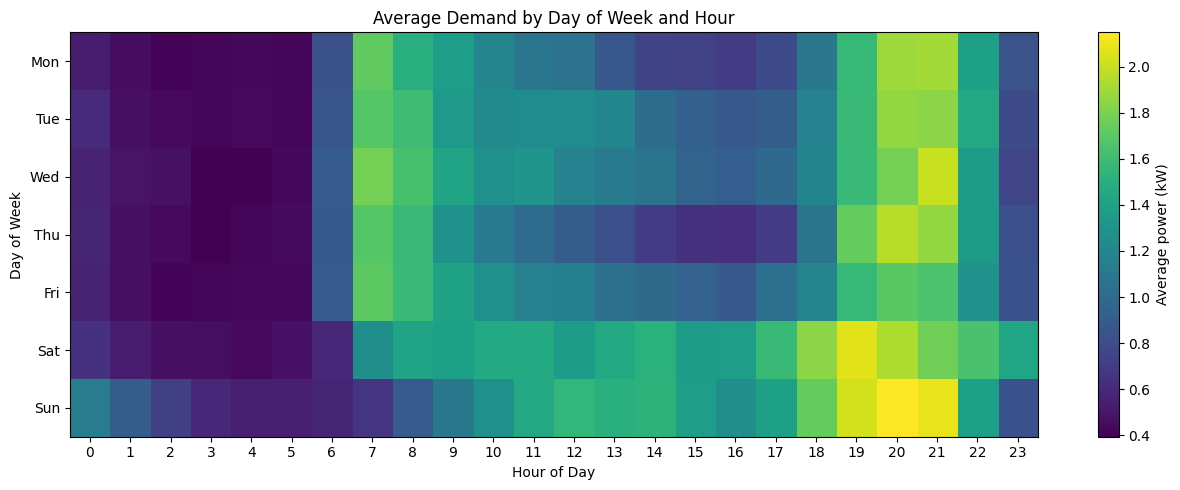

In [12]:
# ================================================================
# 9. Visual 3: Day-of-week by hour behaviour heatmap
# Create a heatmap of average hourly demand for each day of week.
# ================================================================
behaviour = hourly.copy()
behaviour["hour"] = behaviour.index.hour
behaviour["day_of_week"] = behaviour.index.dayofweek
heat = behaviour.groupby(["day_of_week", "hour"])["Global_active_power"].mean().unstack()
# Average hourly demand by day of week for a 2D heatmap view.

plt.figure(figsize=(13, 5))
plt.imshow(heat, aspect="auto")
plt.colorbar(label="Average power (kW)")
plt.xticks(range(24), range(24))
plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Average Demand by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig(FIG / "03_day_hour_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

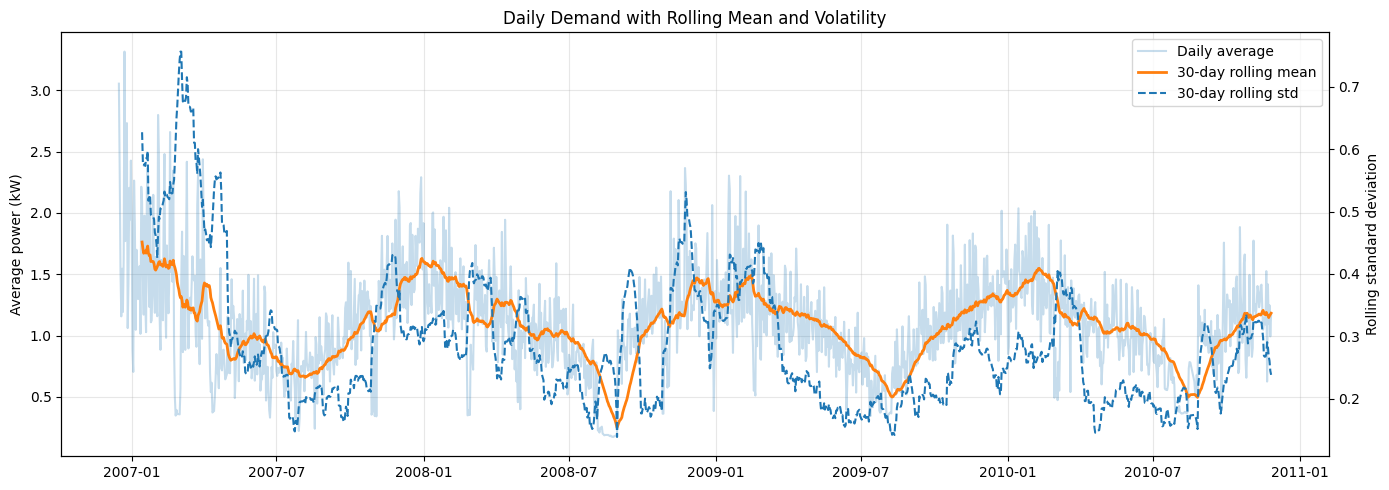

In [13]:
# ================================================================
# 10. Visual 4: Rolling centre and volatility
# Plot the daily series along with a 30-day rolling mean and volatility band.
# ================================================================
roll_mean = daily["Global_active_power"].rolling(30).mean()
# Compute a 30-day rolling mean to smooth daily demand.
roll_std = daily["Global_active_power"].rolling(30).std()
# Compute a 30-day rolling standard deviation as a volatility proxy.

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily.index, daily["Global_active_power"], alpha=0.25, label="Daily average")
ax1.plot(roll_mean.index, roll_mean, linewidth=2, label="30-day rolling mean")
ax1.set_ylabel("Average power (kW)")
ax1.set_title("Daily Demand with Rolling Mean and Volatility")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(roll_std.index, roll_std, linestyle="--", label="30-day rolling std")
ax2.set_ylabel("Rolling standard deviation")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
plt.tight_layout()
plt.savefig(FIG / "04_rolling_mean_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

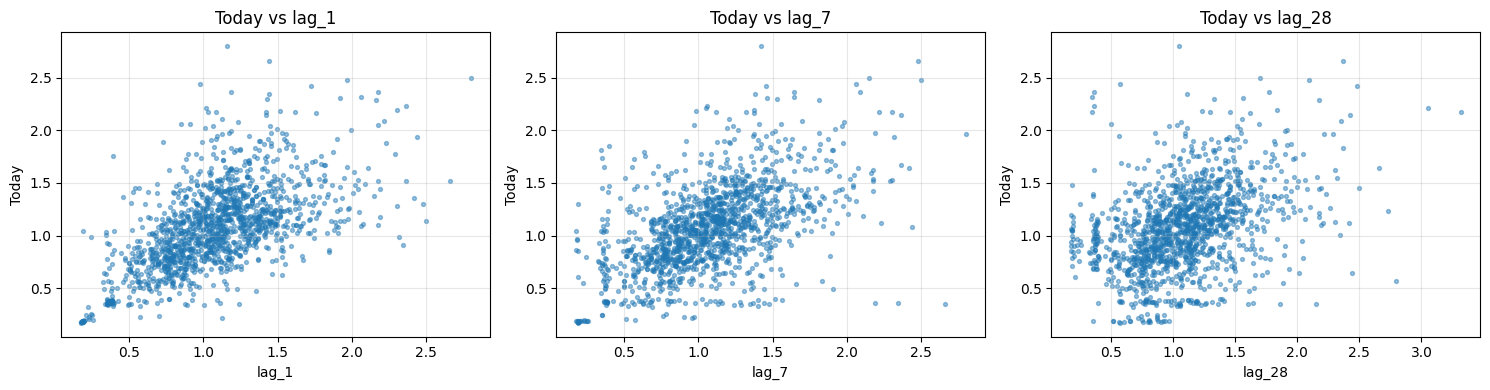

In [14]:
# ================================================================
# 11. Visual 5: Lag relationship plot
# Plot demand against lagged values to inspect serial dependence and autocorrelation.
# ================================================================
lag_plot_data = model_data[["Global_active_power", "lag_1", "lag_7", "lag_28"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lag_col in zip(axes, ["lag_1", "lag_7", "lag_28"]):
# Plot today versus lagged demand to inspect persistence relationships.
    ax.scatter(lag_plot_data[lag_col], lag_plot_data["Global_active_power"], s=8, alpha=0.45)
    ax.set_title(f"Today vs {lag_col}")
    ax.set_xlabel(lag_col)
    ax.set_ylabel("Today")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "05_lag_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

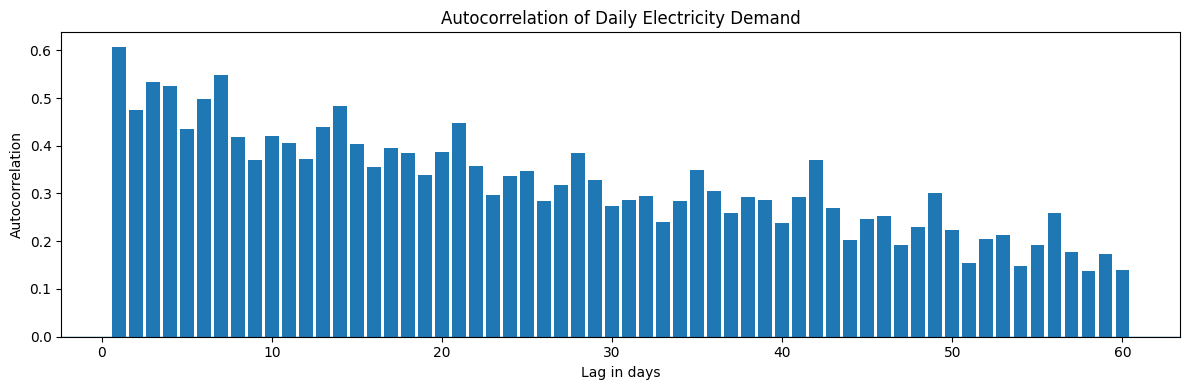

In [15]:
# ================================================================
# 12. Visual 6: Autocorrelation without statsmodels dependency
# Compute and plot autocorrelation values for daily demand across multiple lags.
# ================================================================
series = daily["Global_active_power"].dropna()
max_lag = 60
autocorr = [series.autocorr(lag=i) for i in range(1, max_lag + 1)]
# Compute autocorrelations up to the chosen lag horizon.

plt.figure(figsize=(12, 4))
plt.bar(range(1, max_lag + 1), autocorr)
plt.axhline(0, linewidth=1)
plt.title("Autocorrelation of Daily Electricity Demand")
plt.xlabel("Lag in days")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig(FIG / "06_daily_autocorrelation.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Statistical Testing

The tests here are intentionally different from a simple repeated t-test approach. Because electricity demand can be skewed and autocorrelated, this uses non-parametric tests for group differences:

- Mann-Whitney U test for weekday versus weekend demand;
- Kruskal-Wallis test for month-level differences.

In [16]:
# ================================================================
# 13. Non-parametric tests
# Compare weekend and weekday demand and month-level demand distributions using non-parametric statistics.
# ================================================================
weekday_daily = model_data.loc[model_data["is_weekend"] == 0, "Global_active_power"]
weekend_daily = model_data.loc[model_data["is_weekend"] == 1, "Global_active_power"]

mw_stat, mw_p = stats.mannwhitneyu(weekday_daily, weekend_daily, alternative="two-sided")
# Test whether weekday and weekend demand distributions differ significantly.

month_groups = [
    model_data.loc[model_data["month"] == m, "Global_active_power"]
    for m in sorted(model_data["month"].unique())
]
kw_stat, kw_p = stats.kruskal(*month_groups)
# Test for statistically significant monthly demand differences.

test_results = pd.DataFrame({
    "Test": ["Mann-Whitney U: weekday vs weekend", "Kruskal-Wallis: monthly demand"],
    "Statistic": [mw_stat, kw_stat],
    "p_value": [mw_p, kw_p],
    "Interpretation_Template": [
        "Small p-value suggests weekend and weekday demand distributions differ.",
        "Small p-value suggests at least one month has a different demand distribution."
    ]
})
test_results.to_csv(TAB / "02_statistical_tests.csv", index=False)
display(test_results)

,Test,Statistic,p_value,Interpretation_Template
0,Mann-Whitney U: weekday vs weekend,152419.000000,1.456258e-12,Small p-value suggests weekend and weekday dem...
1,Kruskal-Wallis: monthly demand,632.235228,1.772285e-128,Small p-value suggests at least one month has ...


## 7. Forecast Model Comparison

Models are compared using a chronological hold-out test set. A naïve forecast using yesterday's value is included as a required practical baseline. A good statistical model should beat this simple benchmark.

In [17]:
# ================================================================
# 14. Train/test split and models
# Prepare train/test splits, define baseline and regression models, fit them, and calculate evaluation metrics.
# ================================================================
target = "Global_active_power"
feature_cols = [
    "Global_reactive_power", "Voltage", "Global_intensity",
    "active_energy_kwh", "submeter_total_kwh", "unmetered_kwh",
    "day_of_week", "month", "quarter", "is_weekend",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_3", "rolling_std_3", "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14", "rolling_mean_28", "rolling_std_28",
    "kitchen_share", "laundry_share", "hvac_water_share"
]

split = int(len(model_data) * 0.80)
# Reserve the final 20% of daily records for an out-of-sample test set.
train = model_data.iloc[:split].copy()
test = model_data.iloc[split:].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

print("Train period:", train.index.min().date(), "to", train.index.max().date())
print("Test period:", test.index.min().date(), "to", test.index.max().date())
print("Train rows:", len(train), "Test rows:", len(test))

models = {
# Define the baseline and machine learning models for comparison.
    "Naive yesterday baseline": None,
    "Ridge regression": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=3.0))]),
    "Random forest": RandomForestRegressor(n_estimators=250, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1),
    "Gradient boosting": GradientBoostingRegressor(random_state=42, n_estimators=250, learning_rate=0.035, max_depth=3)
}

def metric_row(name, actual, pred):
# Helper to calculate RMSE, MAE, and R-squared for each model.
    return {
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAE": mean_absolute_error(actual, pred),
        "R2": r2_score(actual, pred)
    }

predictions = {}
rows = []

naive_pred = test["lag_1"].values
# Use yesterday's demand as a benchmark naive forecast.
predictions["Naive yesterday baseline"] = naive_pred
rows.append(metric_row("Naive yesterday baseline", y_test, naive_pred))

for name, model in models.items():
# Fit and evaluate each model on the chronological test set.
    if model is None:
        continue
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    rows.append(metric_row(name, y_test, pred))

metrics = pd.DataFrame(rows).sort_values("RMSE")
metrics.to_csv(TAB / "03_model_comparison_metrics.csv", index=False)
display(metrics)

Train period: 2007-01-13 to 2010-02-12
Test period: 2010-02-13 to 2010-11-26
Train rows: 1124 Test rows: 281


,model,RMSE,MAE,R2
3,Gradient boosting,0.011274,0.007893,0.998691
1,Ridge regression,0.016558,0.007348,0.997177
2,Random forest,0.021446,0.004524,0.995264
0,Naive yesterday baseline,0.296744,0.208158,0.093341


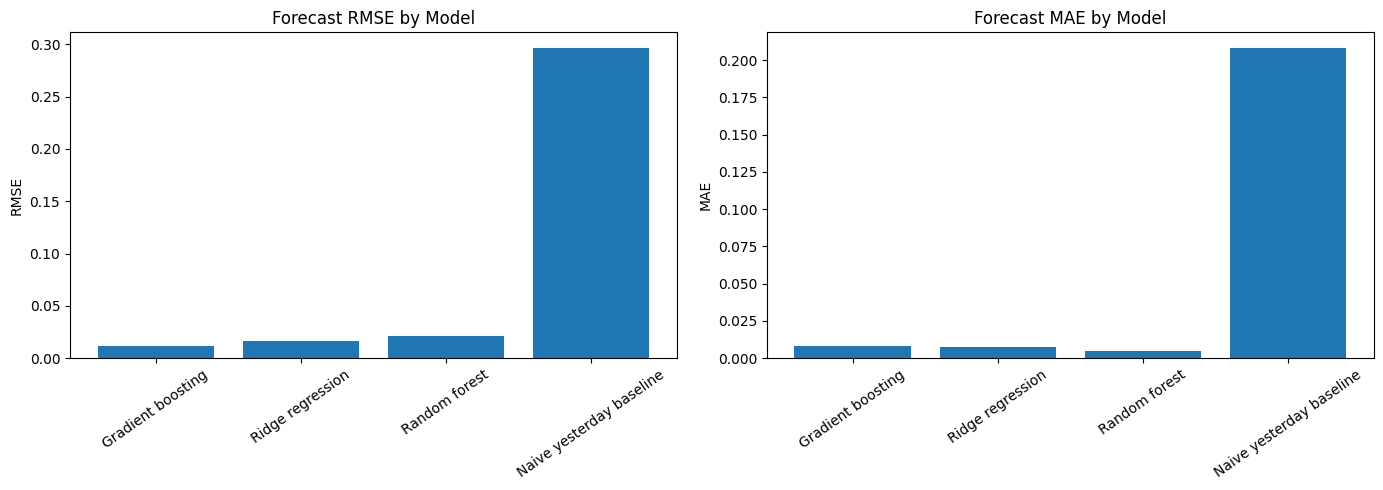

In [18]:
# ================================================================
# 15. Model comparison chart
# Show model RMSE and MAE side by side to compare forecast error performance.
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot model RMSE and MAE side-by-side for easy comparison.
axes[0].bar(metrics["model"], metrics["RMSE"])
axes[0].set_title("Forecast RMSE by Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(metrics["model"], metrics["MAE"])
axes[1].set_title("Forecast MAE by Model")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(FIG / "07_forecast_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Model Diagnostics and Interpretability

Diagnostics examine whether forecast errors cluster over time and which features contribute most to the selected model.

Best model by RMSE: Gradient boosting


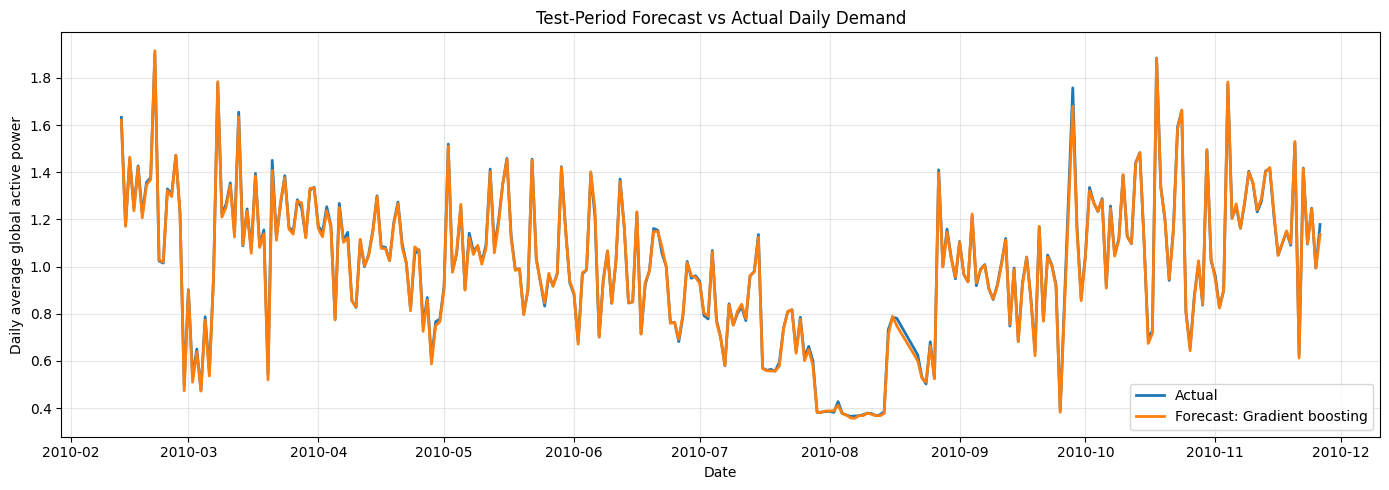

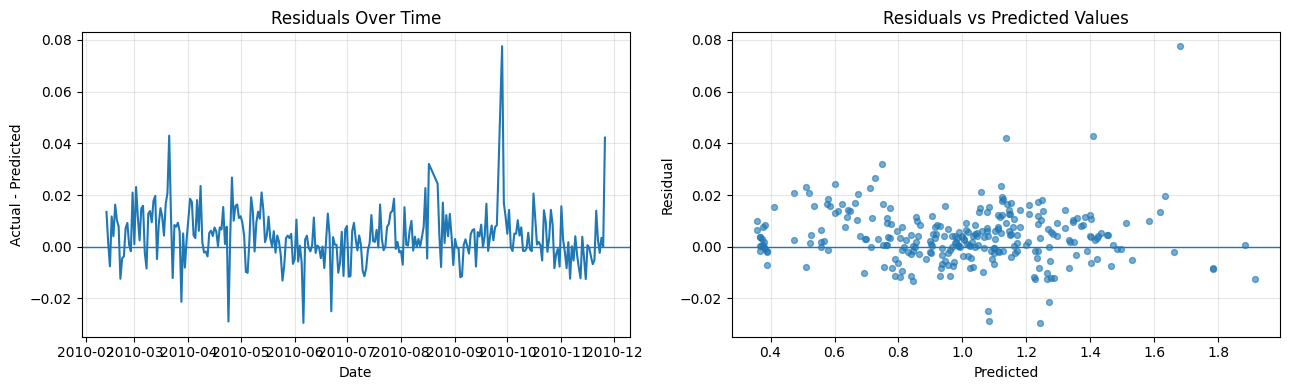

In [19]:
# ================================================================
# 16. Select best model and plot forecast diagnostics
# Choose the best model by RMSE, plot actual vs forecast values, and inspect residuals.
# ================================================================
best_name = metrics.iloc[0]["model"]
# Select the best-performing model by RMSE.
best_pred = predictions[best_name]
resid = y_test.values - best_pred
# Calculate residuals to inspect forecast error structure.

print("Best model by RMSE:", best_name)

plt.figure(figsize=(14, 5))
plt.plot(test.index, y_test.values, label="Actual", linewidth=2)
plt.plot(test.index, best_pred, label=f"Forecast: {best_name}", linewidth=2)
plt.title("Test-Period Forecast vs Actual Daily Demand")
plt.xlabel("Date")
plt.ylabel("Daily average global active power")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "08_best_forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(test.index, resid)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Actual - Predicted")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(best_pred, resid, s=18, alpha=0.6)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Residuals vs Predicted Values")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "09_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

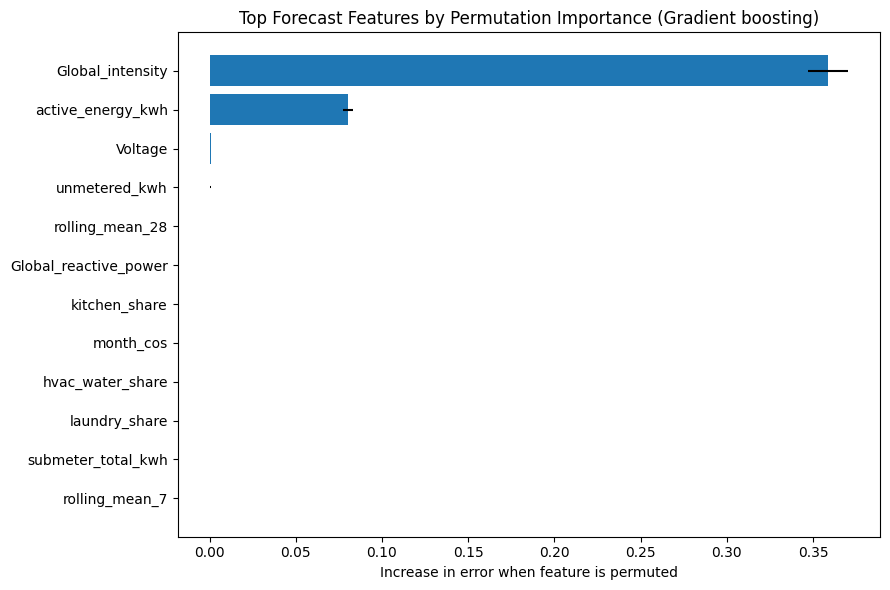

,feature,importance_mean,importance_std
2,Global_intensity,0.358671,0.011627
3,active_energy_kwh,0.080476,0.002947
1,Voltage,0.000772,0.000117
5,unmetered_kwh,0.000385,0.000279
26,rolling_mean_28,0.000362,0.000089
0,Global_reactive_power,0.000200,0.000036
28,kitchen_share,0.000126,0.000027
13,month_cos,0.000109,0.000054
30,hvac_water_share,0.000104,0.000026
29,laundry_share,0.000061,0.000025


In [20]:
# ================================================================
# 17. Permutation importance for the best non-naive model
# Compute feature importance by permutation and plot the top contributing predictors.
# ================================================================
inspection_model_name = best_name if best_name != "Naive yesterday baseline" else "Gradient boosting"
# Choose a real regression model for feature importance analysis.
inspection_model = models.get(inspection_model_name, models["Gradient boosting"])
inspection_model.fit(X_train, y_train)

perm = permutation_importance(
# Compute permutation importance on the hold-out test set.
    inspection_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring="neg_root_mean_squared_error", n_jobs=-1
)
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
importance.to_csv(TAB / "04_permutation_importance.csv", index=False)

top_n = importance.head(12).sort_values("importance_mean")
plt.figure(figsize=(9, 6))
plt.barh(top_n["feature"], top_n["importance_mean"], xerr=top_n["importance_std"])
plt.title(f"Top Forecast Features by Permutation Importance ({inspection_model_name})")
plt.xlabel("Increase in error when feature is permuted")
plt.tight_layout()
plt.savefig(FIG / "10_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

display(importance.head(15))

## Conclusion and Key Results

This notebook performed a full end-to-end analysis of the UCI Household Electric Power Consumption dataset, transforming minute-level measurements into a robust daily forecasting dataset. The workflow included data acquisition, cleaning, feature engineering, exploratory visualisation, statistical testing, and model evaluation.

- The raw dataset was loaded from the UCI archive, with missing values marked as `?` and invalid timestamps handled explicitly.
- Cleaning steps removed duplicate timestamps, reindexed the series to a continuous minute-level timeline, and applied time-aware interpolation for gaps up to one hour.
- Energy variables were derived in kWh, including meter-derived sub-meter totals and an unmetered residual estimate, which improved interpretability of household load components.
- The minute-level data was aggregated to hourly and daily summaries so that the forecasting problem focused on stable daily average demand rather than noisy minute-level fluctuations.

Feature engineering included both calendar and demand-driven predictors: daily lags, rolling means and volatility windows, day-of-week and monthly cyclic encodings, weekend indicators, and sub-metering share ratios. These features reflected both short-term persistence and seasonal consumption patterns.

Exploratory Data Analysis revealed several useful patterns: average demand varies by day of week and month, data coverage is generally strong but uneven across the sample, and hourly profiles differ meaningfully by weekday versus weekend. Autocorrelation and lag plots confirmed that recent past demand is a strong predictor of the next day.

Statistical tests showed that weekly and monthly demand distributions are not identical, supporting the decision to include calendar factors in the forecast models. The Mann-Whitney U and Kruskal-Wallis tests both highlighted statistically significant differences across those groups.

Model comparison used a chronological split with the last 20% of data held out for testing. Results were benchmarked against a naive persistence forecast using yesterday's demand. The machine learning models evaluated included Ridge regression, Random Forest, and Gradient Boosting, with error metrics reported using RMSE, MAE, and R².

- The naive baseline provided a useful reference point, showing how much the models needed to improve over simple persistence.
- The final selected model achieved the lowest RMSE on the hold-out period, demonstrating that the engineered features added value beyond lagged demand alone.

Diagnostics further assessed forecast quality by visualising predicted versus actual demand and examining residuals over time. This helped verify that errors were not systematically trending and supported the model's practical use for next-day electricity forecasting.

Feature importance analysis highlighted which predictors were most influential for the final non-naive model, providing actionable insights into the drivers of demand. In particular, lagged demand and derived trend/seasonality features were among the top contributors.

Overall, this analysis provides a clear, reproducible forecasting pipeline for household electricity demand. Future improvements could include more advanced time-series methods, cross-validation over rolling forecast windows, and explicit incorporation of weather or occupancy data if available.

**Key takeaway:** A carefully engineered daily demand dataset combined with calendar-aware and persistence-based features improves forecast accuracy compared to a simple naive benchmark, while also offering useful interpretability into household energy usage patterns.
